In [8]:
import pandas as pd
from io import StringIO
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from adjustText import adjust_text
import seaborn as sns
import scanpy as sc

In [9]:
def load_arial(arial_folder_path):
    from pathlib import Path
    from matplotlib import font_manager, rcParams
    for font_path in Path(arial_folder_path).glob('*.TTF'):
        font_manager.fontManager.addfont(str(font_path))

    arial_n = {'fontproperties':font_manager.FontProperties(fname="misc/arial/ARIALN.TTF")}
    arial_nb = {'fontproperties':font_manager.FontProperties(fname="misc/arial/ARIALNB.TTF")}

    assert 'Arial' in [f.name for f in font_manager.fontManager.ttflist]

    rcParams['font.family'] = 'sans-serif'
    rcParams['font.sans-serif'] = ['Arial']
    rcParams['ps.fonttype'] = 42
    rcParams['pdf.fonttype'] = 42

    rcParams['mathtext.fontset'] = 'custom'
    rcParams['mathtext.rm'] = 'Arial'
    rcParams['mathtext.it'] = 'Arial:italic'
    rcParams['mathtext.bf'] = 'Arial:bold'

    return arial_n, arial_nb
load_arial('/stor/home/tms4478/work/Arial')

({'fontproperties': <matplotlib.font_manager.FontProperties at 0x783fda51b9a0>},
 {'fontproperties': <matplotlib.font_manager.FontProperties at 0x7841f792fe80>})

In [10]:
class IPA:
    def __init__(self, filepath: str, molecules_filepath=None):
        self.filepath = filepath
        self.pathways = None
        self.upstream_regulators = None
        self.causal_networks = None
        self.regulator_effects = None
        self.analysis_molecules = None
        self.molecules = pd.DataFrame()
        
        self._parse_file()

        if molecules_filepath:
            self.add_molecules(molecules_filepath)

    def __repr__(self):
        return f'IPA Analysis Result with:\n\t{self.pathways.shape[0]} pathways\n\t{self.upstream_regulators.shape[0]} upstream regulators\n\t{self.causal_networks.shape[0]} causal networks\n\t{self.regulator_effects.shape[0]} regulator effects\n\t{self.analysis_molecules.shape[0]} analysis-ready molecules\n\t{self.molecules.shape[0]} molecules'

    def _extract_table(self, lines, start_header, end_condition):
        table_lines = []
        in_table = False

        for line in lines:
            if not in_table and line.startswith(start_header):
                in_table = True
                continue  # skip header line itself

            if in_table:
                if end_condition(line):
                    break
                table_lines.append(line)

        if not table_lines:
            return None

        table_str = "\n".join(table_lines).strip()
        df = pd.read_table(StringIO(table_str), sep="\t", index_col=False)
        df.columns = df.columns.str.strip()
        return df

    def _parse_file(self):
        with open(self.filepath, "r", encoding="utf-8", errors="ignore") as f:
            lines = [line.rstrip("\n") for line in f]

        try:
            self.pathways = self._extract_table(
                lines,
                "Canonical Pathways for",
                lambda l: l.strip() == ""
            )
            self.pathways = self.pathways.set_index('Ingenuity Canonical Pathways')
        except pd.errors.EmptyDataError:
            self.pathways = pd.DataFrame()

        try:
            self.upstream_regulators = self._extract_table(
                lines,
                "Upstream Regulators for",
                lambda l: l.strip() == ""
            )
        except pd.errors.EmptyDataError:
            self.upstream_regulators = pd.DataFrame()

        try:
            self.causal_networks = self._extract_table(
                lines,
                "Causal Networks for",
                lambda l: l.strip() == ""
            )
        except pd.errors.EmptyDataError:
            self.causal_networks = pd.DataFrame()

        try:
            self.regulator_effects = self._extract_table(
                lines,
                "Regulator Effects for",
                lambda l: l.startswith("Networks for")
            )
        except pd.errors.EmptyDataError:
            self.regulator_effects = pd.DataFrame()

        try:
            self.analysis_molecules = self._extract_table(
                lines,
                "Analysis Ready Molecules for",
                lambda l: l.strip() == ""
            )
        except pd.errors.EmptyDataError:
            self.analysis_molecules = pd.DataFrame()

    def add_molecules(self, filepath):
        self.molecules = pd.read_table(filepath, header=1, index_col=0)

    def get_pathways(self, min_p = 0., min_abs_z=None, min_z=None, max_z=None, min_ratio=0., search_genes_any=[], search_genes_all=[], non_nan=False, sort_values=None):
        mask = (self.pathways['-log(p-value)'] >= min_p) & \
            (self.pathways['Ratio'] >= min_ratio)

        if min_abs_z:
            mask = mask & (np.abs(self.pathways['zScore']) >= min_abs_z) 

        if min_z:
            mask = mask & (self.pathways['zScore'] >= min_z)

        if max_z:
            mask = mask & (self.pathways['zScore'] <= max_z)

        if non_nan:
            mask = mask & ~np.any(pd.isna(self.pathways), axis=1)

        if isinstance(search_genes_any, str):
            mask = mask & self.pathways['Molecules'].str.contains(search_genes_any)
        elif len(search_genes_any) > 0:
            np.any([self.pathways['Molecules'].str.contains(gene) for gene in search_genes_any], axis=0)

        if isinstance(search_genes_all, str):
            mask = mask & self.pathways['Molecules'].str.contains(search_genes_all)
        elif len(search_genes_all) > 0:
            np.all([self.pathways['Molecules'].str.contains(gene) for gene in search_genes_all], axis=0)

        if sort_values:
            return self.pathways.loc[mask, :].sort_values(sort_values, ascending=False)
        else:
            return self.pathways.loc[mask, :]
        
    def get_molecules(self, min_lfc=-np.inf, max_lfc=np.inf, min_abs_lfc=0, max_p=1., locations=None, types=None, sort_values=None):
        mask = (self.molecules['Expr Log Ratio'] <= max_lfc) & \
            (self.molecules['Expr Log Ratio'] >= min_lfc) & \
            (np.abs(self.molecules['Expr Log Ratio']) >= min_abs_lfc) & \
            (self.molecules['Expr p-value'] <= max_p)
            
        if locations:
            mask = mask & np.isin(self.molecules['Location'], locations)

        if types:
            mask = mask & np.isin(self.molecules['Type(s)'], types)

        
        if sort_values:
            return self.molecules.loc[mask, :].sort_values(sort_values)
        else:
            return self.molecules.loc[mask, :]

In [11]:
def paths_barplot(paths_df, title=None, sig_line=True, cbar_height=0.3):
    fig, axs = plt.subplots(1, 2, figsize=(6, paths_df.shape[0]/4+0.2), gridspec_kw={'width_ratios': [20, 1]})

    ps = 10**(paths_df['-log(p-value)'])
    zs = paths_df['zScore']
    max_z = np.max(np.abs(zs))
    zs_n = (zs/max_z)/2+0.5

    axs[0].barh(paths_df.index, ps, color=[colormaps['coolwarm'](z) for z in zs_n], linewidth=1, edgecolor='black')

    if sig_line:    
        axs[0].vlines(1/0.05, paths_df.shape[0]+1, -2, linestyles='--', color='black')

    axs[0].set_xscale('log')
    axs[0].set_xlim(1, axs[0].get_xlim()[1])
    axs[0].set_xticklabels([l.get_text().replace('10^{', '10^{-') .replace('10^{-0}', '10^{0}') for l in axs[0].get_xticklabels()])
    axs[0].set_xlabel('$p$-value')

    axs[0].yaxis.set_inverted(True)
    axs[0].set_ylim(paths_df.shape[0], -1)

    if title:
        axs[0].set_title(title, fontweight='bold')

    fig.colorbar(ScalarMappable(norm=Normalize(vmin=-max_z, vmax=max_z), cmap='coolwarm'), cax=axs[1])
    
    cb_pos = axs[1].get_position()
    axs[1].set_position([cb_pos.x0-0.05, (cb_pos.y0+cb_pos.height/2)-(cbar_height/2), cb_pos.width, cbar_height])
    axs[1].set_title('$Z$-score', fontsize='medium', ha='left')
    #plt.tight_layout()

    return paths_df.index

In [12]:
def grouped_heatmap(adatas, ipa, groupby, pathways, ad_labels=None, rename_obs={}, colorbar_title='Mean scaled expression in group', figsize=None, textx=-1.1, texty=-1, xbar_shorten_mult=0.01, xbar_bend_length=0.1, xrot=45, **kwargs):
    _adatas = [sc.pp.scale(ad, copy=True) for ad in adatas]

    gene_sets = ipa.get_pathways().loc[pathways, 'Molecules'].to_dict()
    gene_sets = {g:ipa.get_molecules().loc[gene_sets[g].split(','), 'Expr Log Ratio'].sort_values().index for g in gene_sets.keys()}

    xdim = np.sum([len(ad.obs[groupby].cat.categories) for ad in _adatas])
    ydim = np.sum([len(g) for g in gene_sets.values()])

    heatmap = pd.DataFrame(index=np.concatenate(list(gene_sets.values())), columns=np.concatenate([list(ad.obs[groupby].cat.rename_categories(rename_obs).cat.categories) for ad in _adatas]), dtype=float)# np.zeros((ydim, xdim))
    
    x = 0
    for ad in _adatas:
        for cat in ad.obs[groupby].cat.categories:
            y = 0
            for gene_set in gene_sets.keys():
                for gene in gene_sets[gene_set]:
                    #heatmap[y, x] = np.mean(ad[ad.obs[groupby] == cat, gene].X)
                    if gene in ad.var_names:
                        heatmap.iloc[y,x] = np.mean(ad[ad.obs[groupby] == cat, gene].X)
                    else:
                        heatmap.iloc[y,x] = 0
                    y += 1
            x += 1

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(heatmap, ax=ax, cbar_kws=dict(label=colorbar_title), **kwargs)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=xrot)
    ax.set_yticks(np.arange(ydim)+0.5, np.concatenate(list(gene_sets.values())))

    y = 0
    for gene_set in gene_sets.keys():
        dy = len(gene_sets[gene_set])
        ax.text(textx*1.1, dy/2+y, gene_set, rotation=90, va='center', ha='right', fontweight='bold')
        lines = []
        lines.append(ax.vlines(textx, y+ydim*xbar_shorten_mult, dy+y-ydim*xbar_shorten_mult, color='black', linewidth=1))
        lines.append(ax.hlines(y+ydim*xbar_shorten_mult, textx, textx*(1-xbar_bend_length), color='black', linewidth=1))
        lines.append(ax.hlines(dy+y-ydim*xbar_shorten_mult, textx, textx*(1-xbar_bend_length), color='black', linewidth=1))
        for line in lines:
            line.set_clip_on(False)
        y += dy
        if y != ydim:
            ax.hlines(y, 0, xdim, color='black', linewidth=1)

    if ad_labels:
        x = 0
        for i, ad in enumerate(_adatas):
            dx = len(ad.obs[groupby].cat.categories)
            ax.text(dx/2+x, texty, ad_labels[i], va='top', ha='center', fontweight='bold')
            x += dx


In [13]:
def grouped_heatmap_lin(adata, ipa, groupby, pathways, lin_labels, colorbar_title='Mean scaled expression in group', figsize=None, textx=-1.1, texty=-1, bar_shorten_mult=0.01, bar_bend_length=0.1, xrot=45, **kwargs):
    _adata = adata.copy() # sc.pp.scale(adata, copy=True)

    gene_sets = {pathway:ipa.get_pathways().at[pathway.replace('\n', ' '), 'Molecules'] for pathway in pathways}
    gene_sets = {g:ipa.get_molecules().loc[gene_sets[g].split(','), 'Expr Log Ratio'].sort_values().index for g in gene_sets.keys()}

    xdim = np.sum([len(l) for l in lin_labels.values()])
    ydim = np.sum([len(g) for g in gene_sets.values()])

    heatmap = pd.DataFrame(index=np.concatenate(list(gene_sets.values())), columns=np.concatenate(list(lin_labels.values())), dtype=float)# np.zeros((ydim, xdim))
    
    x = 0
    for lin_label in lin_labels:
        for lin in lin_labels[lin_label]:
            y = 0
            for gene_set in gene_sets.keys():
                for gene in gene_sets[gene_set]:
                    #heatmap[y, x] = np.mean(ad[ad.obs[groupby] == cat, gene].X)
                    if gene in _adata.var_names:
                        heatmap.iloc[y,x] = np.mean(_adata[_adata.obs[groupby] == lin, gene].X)
                    else:
                        heatmap.iloc[y,x] = 0
                    y += 1
            x += 1

    heatmap = ((heatmap.T-heatmap.mean(axis=1))/heatmap.std(axis=1)).T

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(heatmap, ax=ax, cbar_kws=dict(label=colorbar_title), **kwargs)
    ax.set_xticklabels([])

    y = 0
    for gene_set in gene_sets.keys():
        dy = len(gene_sets[gene_set])
        ax.text(textx*1.1, dy/2+y, gene_set, rotation=90, va='center', ha='right', ma='center', fontweight='bold', size='small')
        lines = []
        lines.append(ax.vlines(textx, y+ydim*bar_shorten_mult, dy+y-ydim*bar_shorten_mult, color='black', linewidth=1))
        lines.append(ax.hlines(y+ydim*bar_shorten_mult, textx, textx*(1-bar_bend_length), color='black', linewidth=1))
        lines.append(ax.hlines(dy+y-ydim*bar_shorten_mult, textx, textx*(1-bar_bend_length), color='black', linewidth=1))
        for line in lines:
            line.set_clip_on(False)
        y += dy
        if y != ydim:
            ax.hlines(y, 0, xdim, color='black', linewidth=1)

    x = 0
    for lin_label in lin_labels.keys():
        dx = len(lin_labels[lin_label])
        ax.text(dx/2+x, texty*1.1, lin_label, va='bottom', ha='center', fontweight='bold')
        lines = []
        lines.append(ax.hlines(texty, x+xdim*bar_shorten_mult, dx+x-xdim*bar_shorten_mult, color='black', linewidth=1))
        lines.append(ax.vlines(x+xdim*bar_shorten_mult, texty, texty*(1-bar_bend_length), color='black', linewidth=1))
        lines.append(ax.vlines(dx+x-xdim*bar_shorten_mult, texty, texty*(1-bar_bend_length), color='black', linewidth=1))
        for line in lines:
            line.set_clip_on(False)
        x += dx
        if x != xdim:
            ax.vlines(dx, 0, ydim, color='black', linewidth=1) 

# Load in Data

In [16]:
# HK177 Lineages
misubp_vs_nonmisubp_in_bottom = IPA('IPA_output/hk177/summaries/misubp_vs_nonmisubp_in_bottom.txt', molecules_filepath='IPA_output/hk177/molecules/misubp_vs_nonmisubp_in_bottom.txt')
misubp_vs_nonmisubp_in_softmi= IPA('IPA_output/hk177/summaries/misubp_vs_nonmisubp_in_softmi.txt', molecules_filepath='IPA_output/hk177/molecules/misubp_vs_nonmisubp_in_softmi.txt')
misubp_vs_nonmisubp_in_softnon = IPA('IPA_output/hk177/summaries/misubp_vs_nonmisubp_in_softnon.txt', molecules_filepath='IPA_output/hk177/molecules/misubp_vs_nonmisubp_in_softnon.txt')
misubp_vs_nonmisubp_in_stiff= IPA('IPA_output/hk177/summaries/misubp_vs_nonmisubp_in_stiff.txt', molecules_filepath='IPA_output/hk177/molecules/misubp_vs_nonmisubp_in_stiff.txt')
#misubp_vs_nonmisubp_in_soft = IPA('hk177/summaries/misubp_vs_nonmisubp_in_soft.txt', molecules_filepath='hk177/molecules/misubp_vs_nonmisubp_in_soft.txt')
misubp_vs_nonmisubp_in_stiffnon = IPA('IPA_output/hk177/summaries/misubp_vs_nonmisubp_in_stiffnon.txt', molecules_filepath='IPA_output/hk177/molecules/misubp_vs_nonmisubp_in_stiffnon.txt')
misubp_vs_nonmisubp_in_top = IPA('IPA_output/hk177/summaries/misubp_vs_nonmisubp_in_top.txt', molecules_filepath='IPA_output/hk177/molecules/misubp_vs_nonmisubp_in_top.txt')
misubp_vs_nonmisubp = IPA('IPA_output/hk177/summaries/misubp_vs_nonmisubp.txt', molecules_filepath='IPA_output/hk177/molecules/misubp_vs_nonmisubp.txt')

In [17]:
# HK177
hk177_softmi_vs_softnon= IPA('IPA_output/hk177/summaries/softmi_vs_softnon.txt', molecules_filepath='IPA_output/hk177/molecules/softmi_vs_softnon.txt')
hk177_stiff_vs_soft= IPA('IPA_output/hk177/summaries/stiff_vs_soft.txt', molecules_filepath='IPA_output/hk177/molecules/stiff_vs_soft.txt')
hk177_stiffmi_vs_softmi = IPA('IPA_output/hk177/summaries/stiffmi_vs_softmi.txt', molecules_filepath='IPA_output/hk177/molecules/stiffmi_vs_softmi.txt')
hk177_stiffmi_vs_stiffnon= IPA('IPA_output/hk177/summaries/stiffmi_vs_stiffnon.txt', molecules_filepath='IPA_output/hk177/molecules/stiffmi_vs_stiffnon.txt')
hk177_stiffnon_vs_softnon = IPA('IPA_output/hk177/summaries/stiffnon_vs_softnon.txt', molecules_filepath='IPA_output/hk177/molecules/stiffnon_vs_softnon.txt')
hk177_top_vs_bottom = IPA('IPA_output/hk177/summaries/top_vs_bottom.txt', molecules_filepath='IPA_output/hk177/molecules/top_vs_bottom.txt')

In [18]:
# GS54
gs54_softmi_vs_softnon= IPA('IPA_output/gs54/summaries/softmi_vs_softnon.txt', molecules_filepath='IPA_output/gs54/molecules/softmi_vs_softnon.txt')
gs54_stiff_vs_soft= IPA('IPA_output/gs54/summaries/stiff_vs_soft.txt', molecules_filepath='IPA_output/gs54/molecules/stiff_vs_soft.txt')
gs54_stiffmi_vs_softmi = IPA('IPA_output/gs54/summaries/stiffmi_vs_softmi.txt', molecules_filepath='IPA_output/gs54/molecules/stiffmi_vs_softmi.txt')
gs54_stiffmi_vs_stiffnon= IPA('IPA_output/gs54/summaries/stiffmi_vs_stiffnon.txt', molecules_filepath='IPA_output/gs54/molecules/stiffmi_vs_stiffnon.txt')
gs54_stiffnon_vs_softnon = IPA('IPA_output/gs54/summaries/stiffnon_vs_softnon.txt', molecules_filepath='IPA_output/gs54/molecules/stiffnon_vs_softnon.txt')
gs54_top_vs_bottom = IPA('IPA_output/gs54/summaries/top_vs_bottom.txt', molecules_filepath='IPA_output/gs54/molecules/top_vs_bottom.txt')

In [19]:
# Anndata
ad_hk177 = sc.read_h5ad('HK177_02_processed.h5ad')
ad_hk177 = ad_hk177[:, np.mean(ad_hk177.X != 0., axis=0) > 0.1]

ad_gs54 = sc.read_h5ad('GS54_cleaned.h5ad')
ad_gs54 = ad_gs54[:, np.mean(ad_gs54.X != 0., axis=0) > 0.1]

ad_hk177_sub = ad_hk177[ad_hk177.obs['lineage'] != 'none']

In [20]:
ad_hk177.obs['substrate'] = ['soft' if c.startswith('Soft') else 'stiff' for c in ad_hk177.obs['sample']]
ad_hk177.obs['gel_side'] = ['bottom' if c.endswith('Mi') else 'top' for c in ad_hk177.obs['sample']]

ad_gs54.obs['substrate'] = ['soft' if c.startswith('Soft') else 'stiff' for c in ad_gs54.obs['sample']]
ad_gs54.obs['gel_side'] = ['bottom' if c.endswith('Mi') else 'top' for c in ad_gs54.obs['sample']]

/tmp/ipykernel_4166824/2933220910.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  ad_hk177.obs['substrate'] = ['soft' if c.startswith('Soft') else 'stiff' for c in ad_hk177.obs['sample']]
/tmp/ipykernel_4166824/2933220910.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  ad_gs54.obs['substrate'] = ['soft' if c.startswith('Soft') else 'stiff' for c in ad_gs54.obs['sample']]


# Changes in Cells as they Migrate - HK177

In [21]:
hk177_stiffmi_vs_softmi.get_molecules(
    max_p=0.05,
    min_abs_lfc=0.2,
    sort_values='Expr Log Ratio'
).head(20)

,Entrez Gene Name,Gene Symbol - human (HUGO / HGNC / Entrez Gene),Expr Log Ratio,Expr p-value,Location,Type(s),Biomarker Application(s),Drug(s),Entrez Gene ID for Human,Entrez Gene ID for Mouse,Entrez Gene ID for Rat
Symbol,,,,,,,,,,,
ZNF358,zinc finger protein 358,ZNF358,-0.201,0.031,Nucleus,transcription regulator,NaN,NaN,,,


In [23]:
hk177_softmi_vs_softnon.get_molecules(
    max_p=0.05,
    min_abs_lfc=0.2,
    sort_values='Expr Log Ratio'
).head(20)

,Entrez Gene Name,Gene Symbol - human (HUGO / HGNC / Entrez Gene),Expr Log Ratio,Expr p-value,Location,Type(s),Biomarker Application(s),Drug(s),Entrez Gene ID for Human,Entrez Gene ID for Mouse,Entrez Gene ID for Rat
Symbol,,,,,,,,,,,
IL11,interleukin 11,IL11,-0.823,7.070000e-37,Extracellular Space,cytokine,unspecified application,9MW3811,,,
IER3,immediate early response 3,IER3,-0.784,3.640000e-25,Cytoplasm,other,unspecified application,NaN,,,
CRYAB,crystallin alpha B,CRYAB,-0.689,4.290000e-37,Nucleus,other,"diagnosis,disease progression,prognosis,unspec...",NaN,,,
PPP1R15A,protein phosphatase 1 regulatory subunit 15A,PPP1R15A,-0.658,1.310000e-40,Cytoplasm,other,NaN,icerguastat,,,
COL1A1,collagen type I alpha 1 chain,COL1A1,-0.625,7.660000e-21,Extracellular Space,other,diagnosis,collagenase,,,
HTRA1,HtrA serine peptidase 1,HTRA1,-0.580,4.740000e-19,Extracellular Space,peptidase,NaN,NaN,,,
TGFBI,transforming growth factor beta induced,TGFBI,-0.573,1.130000e-22,Extracellular Space,other,NaN,NaN,,,
DCN,decorin,DCN,-0.563,6.790000e-18,Extracellular Space,other,NaN,NaN,,,
MEG3,maternally expressed 3,MEG3,-0.519,8.020000e-18,Nucleus,other,NaN,NaN,,,


/tmp/ipykernel_4166824/3962488590.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels([l.get_text().replace('10^{', '10^{-') .replace('10^{-0}', '10^{0}') for l in axs[0].get_xticklabels()])


Index(['Respiratory electron transport', 'Oxidative Phosphorylation',
       'Mitochondrial Dysfunction', 'Neutrophil degranulation',
       'Sirtuin Signaling Pathway', 'Mitochondrial translation',
       'Mitochondrial RNA degradation',
       'Neutrophil Extracellular Trap Signaling Pathway',
       'Warburg Effect Signaling Pathway', 'Mitochondrial protein degradation',
       'Ephrin Receptor Signaling',
       'Integrin to Cytoskeleton Signaling Pathway',
       'TP53 Regulates Metabolic Genes', 'Cyclophilin Signaling Pathway',
       'Superpathway of Cholesterol Biosynthesis', 'Cholesterol biosynthesis',
       'Myelination Signaling Pathway', 'rRNA processing',
       'Protein Sorting Signaling Pathway', 'RHO GTPase cycle',
       'tRNA processing in the mitochondrion', 'Glucose metabolism',
       'Asparagine N-linked glycosylation',
       'Insertion of tail-anchored proteins into the endoplasmic reticulum membrane',
       'Z-decay: degradation of maternal mRNAs by zygotical

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


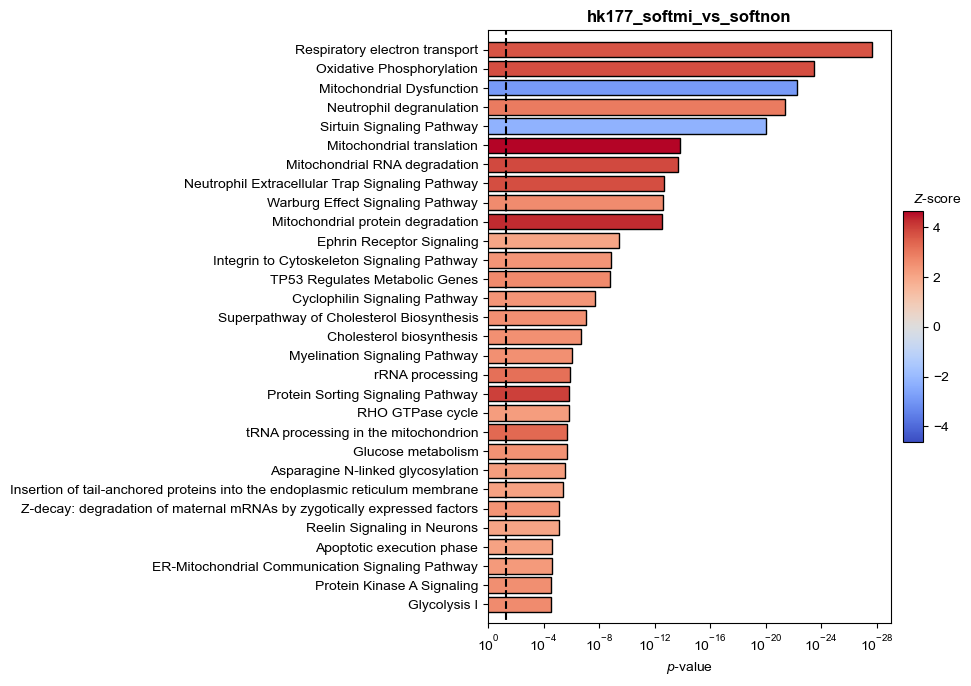

In [24]:
paths_barplot(
    hk177_softmi_vs_softnon.get_pathways(
        min_p=-np.log10(0.00005),
        min_abs_z=2,
        non_nan=True,
        sort_values='-log(p-value)'
    ),
    title='hk177_softmi_vs_softnon'
)

In [25]:
hk177_stiffmi_vs_stiffnon.get_molecules(
    max_p=0.05,
    min_abs_lfc=0.2,
    sort_values='Expr Log Ratio'
).head(20)

,Entrez Gene Name,Gene Symbol - human (HUGO / HGNC / Entrez Gene),Expr Log Ratio,Expr p-value,Location,Type(s),Biomarker Application(s),Drug(s),Entrez Gene ID for Human,Entrez Gene ID for Mouse,Entrez Gene ID for Rat
Symbol,,,,,,,,,,,
COL1A1,collagen type I alpha 1 chain,COL1A1,-1.794,1.520000e-115,Extracellular Space,other,diagnosis,collagenase,,,
SPARC,secreted protein acidic and cysteine rich,SPARC,-1.384,5.810000e-100,Extracellular Space,other,"disease progression,efficacy",NaN,,,
TGFBI,transforming growth factor beta induced,TGFBI,-1.216,2.260000e-107,Extracellular Space,other,NaN,NaN,,,
TNFRSF12A,TNF receptor superfamily member 12A,TNFRSF12A,-1.139,7.430000e-74,Plasma Membrane,transmembrane receptor,NaN,enavatuzumab,,,
FSTL1,follistatin like 1,FSTL1,-1.132,8.170000e-94,Extracellular Space,other,NaN,NaN,,,
DCN,decorin,DCN,-1.032,1.230000e-54,Extracellular Space,other,NaN,NaN,,,
NREP,neuronal regeneration related protein,NREP,-0.984,3.110000e-78,Cytoplasm,other,NaN,NaN,,,
FILIP1L,filamin A interacting protein 1 like,FILIP1L,-0.968,5.830000e-53,Nucleus,other,NaN,NaN,,,
COL3A1,collagen type III alpha 1 chain,COL3A1,-0.907,3.510000e-56,Extracellular Space,other,"diagnosis,efficacy",collagenase,,,


/tmp/ipykernel_4166824/3962488590.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels([l.get_text().replace('10^{', '10^{-') .replace('10^{-0}', '10^{0}') for l in axs[0].get_xticklabels()])


Index(['Mitochondrial Dysfunction', 'Oxidative Phosphorylation',
       'Neutrophil degranulation', 'Respiratory electron transport',
       'Cellular response to hypoxia',
       'Regulation of mRNA stability by proteins that bind AU-rich elements',
       'Protein Ubiquitination Pathway', 'Proteasome assembly',
       'Metabolism of polyamines', 'Hedgehog ligand biogenesis',
       ...
       'Glycolysis I', 'Macroautophagy', 'Cilium Assembly',
       'Interferon alpha/beta signaling', 'Cellular response to heat stress',
       'Membrane Repair Signaling Pathway', 'Collagen degradation',
       'Netrin Signaling',
       'Role of JAK family kinases in IL-6-type Cytokine Signaling',
       'Extra-nuclear estrogen signaling'],
      dtype='object', name='Ingenuity Canonical Pathways', length=126)

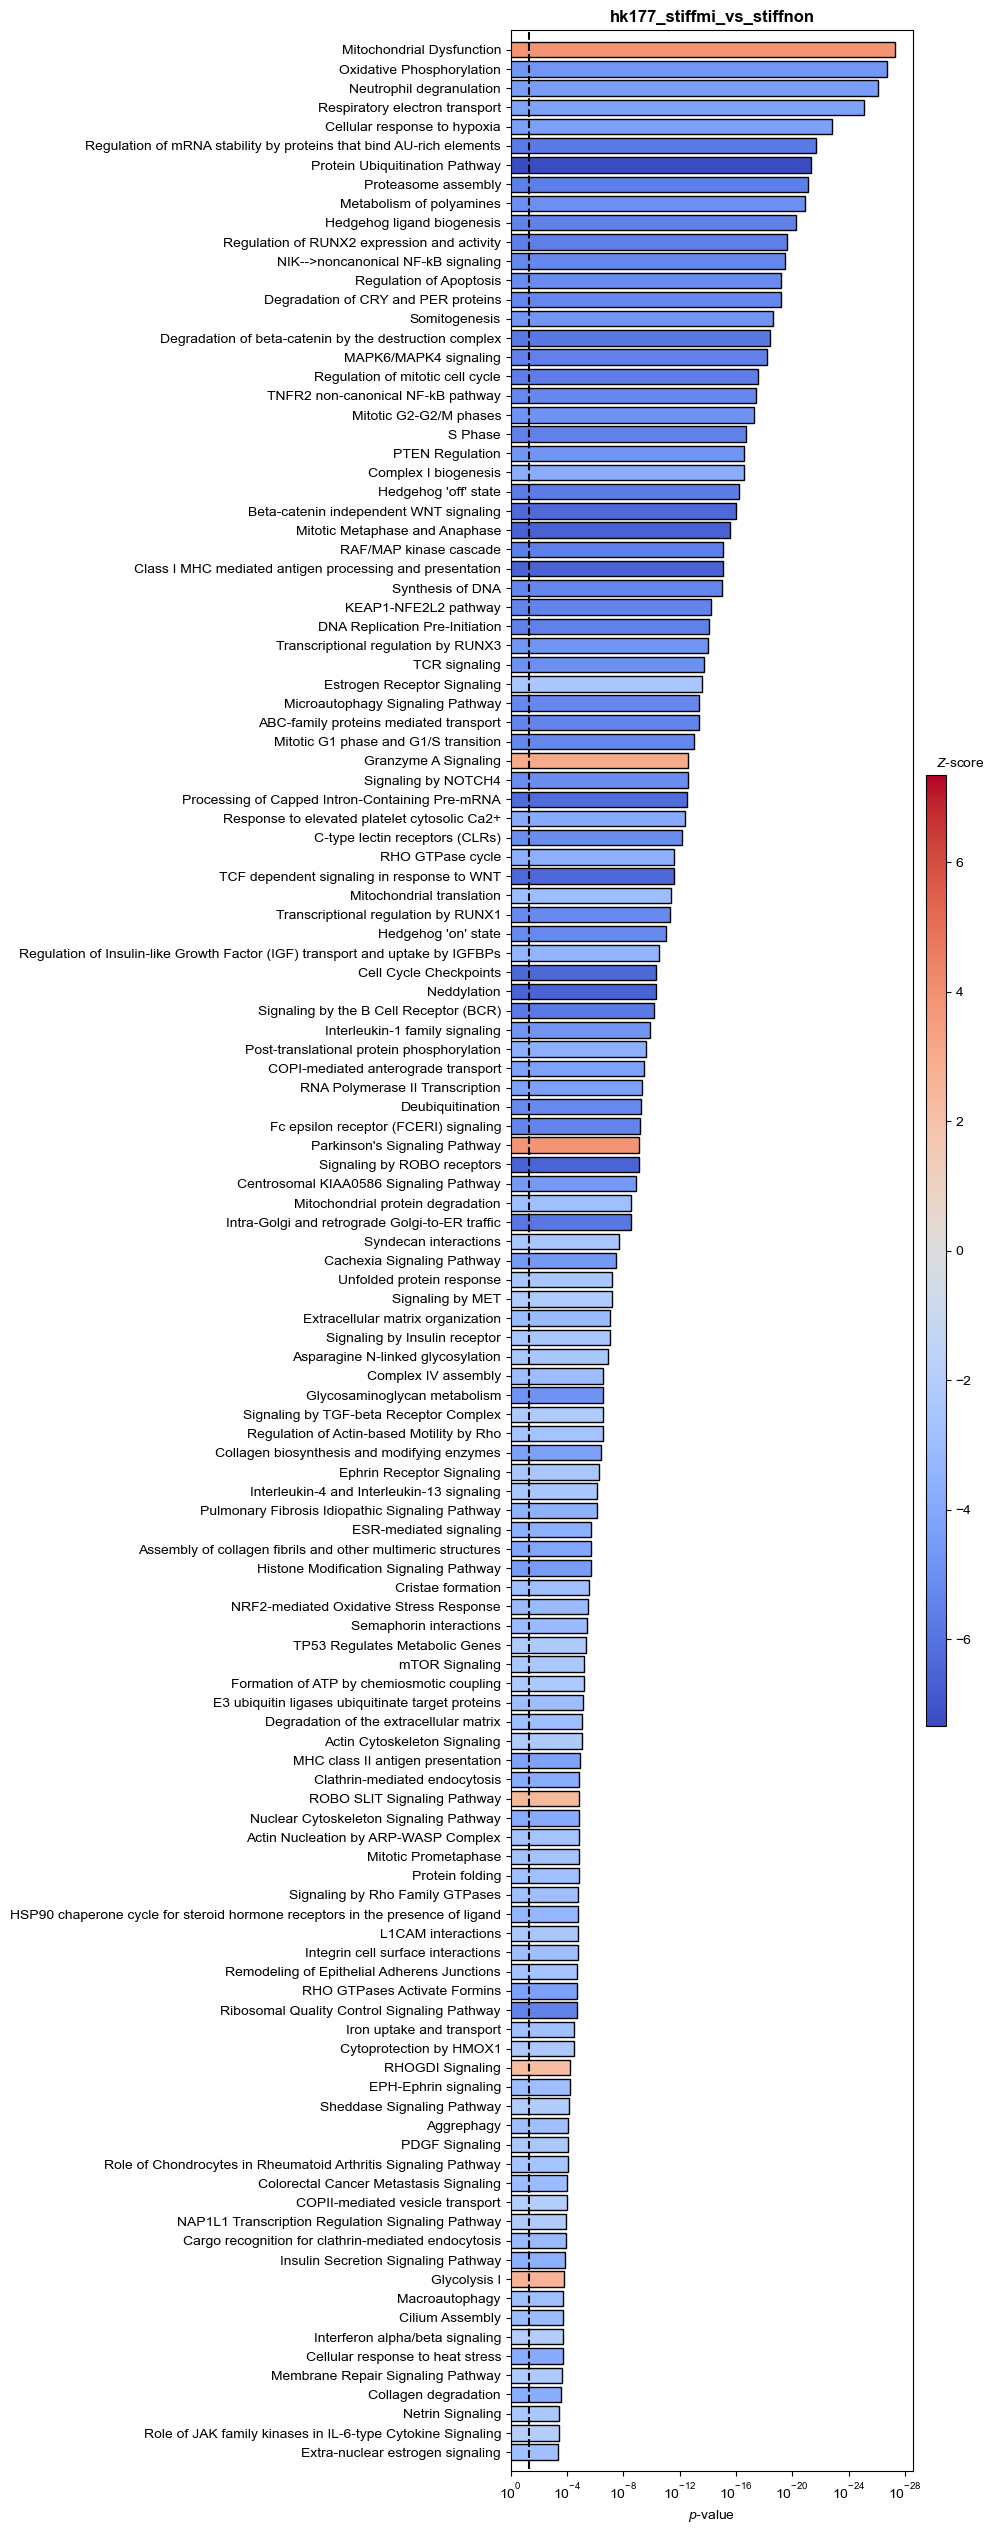

In [26]:
paths_barplot(
    hk177_stiffmi_vs_stiffnon.get_pathways(
        min_p=-np.log10(0.0005),
        min_abs_z=2,
        non_nan=True,
        sort_values='-log(p-value)'
    ),
    title='hk177_stiffmi_vs_stiffnon'
)

/tmp/ipykernel_4166824/3962488590.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels([l.get_text().replace('10^{', '10^{-') .replace('10^{-0}', '10^{0}') for l in axs[0].get_xticklabels()])


Index(['Oxidative Phosphorylation', 'Cellular response to hypoxia',
       'Degradation of beta-catenin by the destruction complex',
       'Asparagine N-linked glycosylation',
       'Extracellular matrix organization',
       'Assembly of collagen fibrils and other multimeric structures',
       'Collagen biosynthesis and modifying enzymes',
       'Regulation of Actin-based Motility by Rho',
       'Actin Cytoskeleton Signaling', 'Collagen degradation'],
      dtype='object', name='Ingenuity Canonical Pathways')

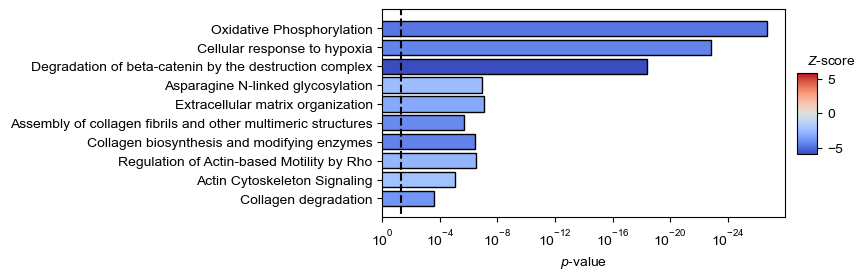

In [27]:
paths_barplot(
    hk177_stiffmi_vs_stiffnon.get_pathways(
        min_p=-np.log10(0.0005),
        min_abs_z=2,
        non_nan=True,
        sort_values='-log(p-value)'
    ).loc[['Oxidative Phosphorylation',
           'Cellular response to hypoxia',
           'Degradation of beta-catenin by the destruction complex',
           'Asparagine N-linked glycosylation',
           'Extracellular matrix organization',
           'Assembly of collagen fibrils and other multimeric structures',
           'Collagen biosynthesis and modifying enzymes',
           'Regulation of Actin-based Motility by Rho',
           'Actin Cytoskeleton Signaling',
           'Collagen degradation'],:],
    title=''
)

In [28]:
hk177_top_vs_bottom.get_molecules(
    max_p=0.05,
    min_abs_lfc=0.2,
    sort_values='Expr Log Ratio'
).head(20)

,Entrez Gene Name,Gene Symbol - human (HUGO / HGNC / Entrez Gene),Expr Log Ratio,Expr p-value,Location,Type(s),Biomarker Application(s),Drug(s),Entrez Gene ID for Human,Entrez Gene ID for Mouse,Entrez Gene ID for Rat
Symbol,,,,,,,,,,,
COL1A1,collagen type I alpha 1 chain,COL1A1,-1.196,2.420000e-123,Extracellular Space,other,diagnosis,collagenase,,,
TGFBI,transforming growth factor beta induced,TGFBI,-0.893,1.370000e-116,Extracellular Space,other,NaN,NaN,,,
SPARC,secreted protein acidic and cysteine rich,SPARC,-0.882,2.230000e-101,Extracellular Space,other,"disease progression,efficacy",NaN,,,
DCN,decorin,DCN,-0.816,1.750000e-73,Extracellular Space,other,NaN,NaN,,,
IL11,interleukin 11,IL11,-0.803,2.730000e-70,Extracellular Space,cytokine,unspecified application,9MW3811,,,
TNFRSF12A,TNF receptor superfamily member 12A,TNFRSF12A,-0.778,4.780000e-72,Plasma Membrane,transmembrane receptor,NaN,enavatuzumab,,,
FSTL1,follistatin like 1,FSTL1,-0.760,6.250000e-104,Extracellular Space,other,NaN,NaN,,,
CRYAB,crystallin alpha B,CRYAB,-0.740,1.860000e-88,Nucleus,other,"diagnosis,disease progression,prognosis,unspec...",NaN,,,
IER3,immediate early response 3,IER3,-0.719,3.640000e-44,Cytoplasm,other,unspecified application,NaN,,,


/tmp/ipykernel_4166824/3962488590.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels([l.get_text().replace('10^{', '10^{-') .replace('10^{-0}', '10^{0}') for l in axs[0].get_xticklabels()])


Index(['Neutrophil degranulation', 'Mitotic G2-G2/M phases',
       'Protein Ubiquitination Pathway', 'Metabolism of polyamines',
       'Regulation of mRNA stability by proteins that bind AU-rich elements',
       'MAPK6/MAPK4 signaling', 'PTEN Regulation', 'Regulation of Apoptosis',
       'NIK-->noncanonical NF-kB signaling',
       'TNFR2 non-canonical NF-kB pathway', 'Regulation of mitotic cell cycle',
       'Degradation of CRY and PER proteins', 'Cellular response to hypoxia',
       'Hedgehog 'off' state', 'Mitotic Metaphase and Anaphase',
       'Regulation of Insulin-like Growth Factor (IGF) transport and uptake by IGFBPs',
       'Proteasome assembly', 'Regulation of RUNX2 expression and activity',
       'Hedgehog ligand biogenesis', 'Beta-catenin independent WNT signaling',
       'Transcriptional regulation by RUNX3',
       'Microautophagy Signaling Pathway', 'RAF/MAP kinase cascade',
       'KEAP1-NFE2L2 pathway', 'Somitogenesis',
       'COPI-mediated anterograde trans

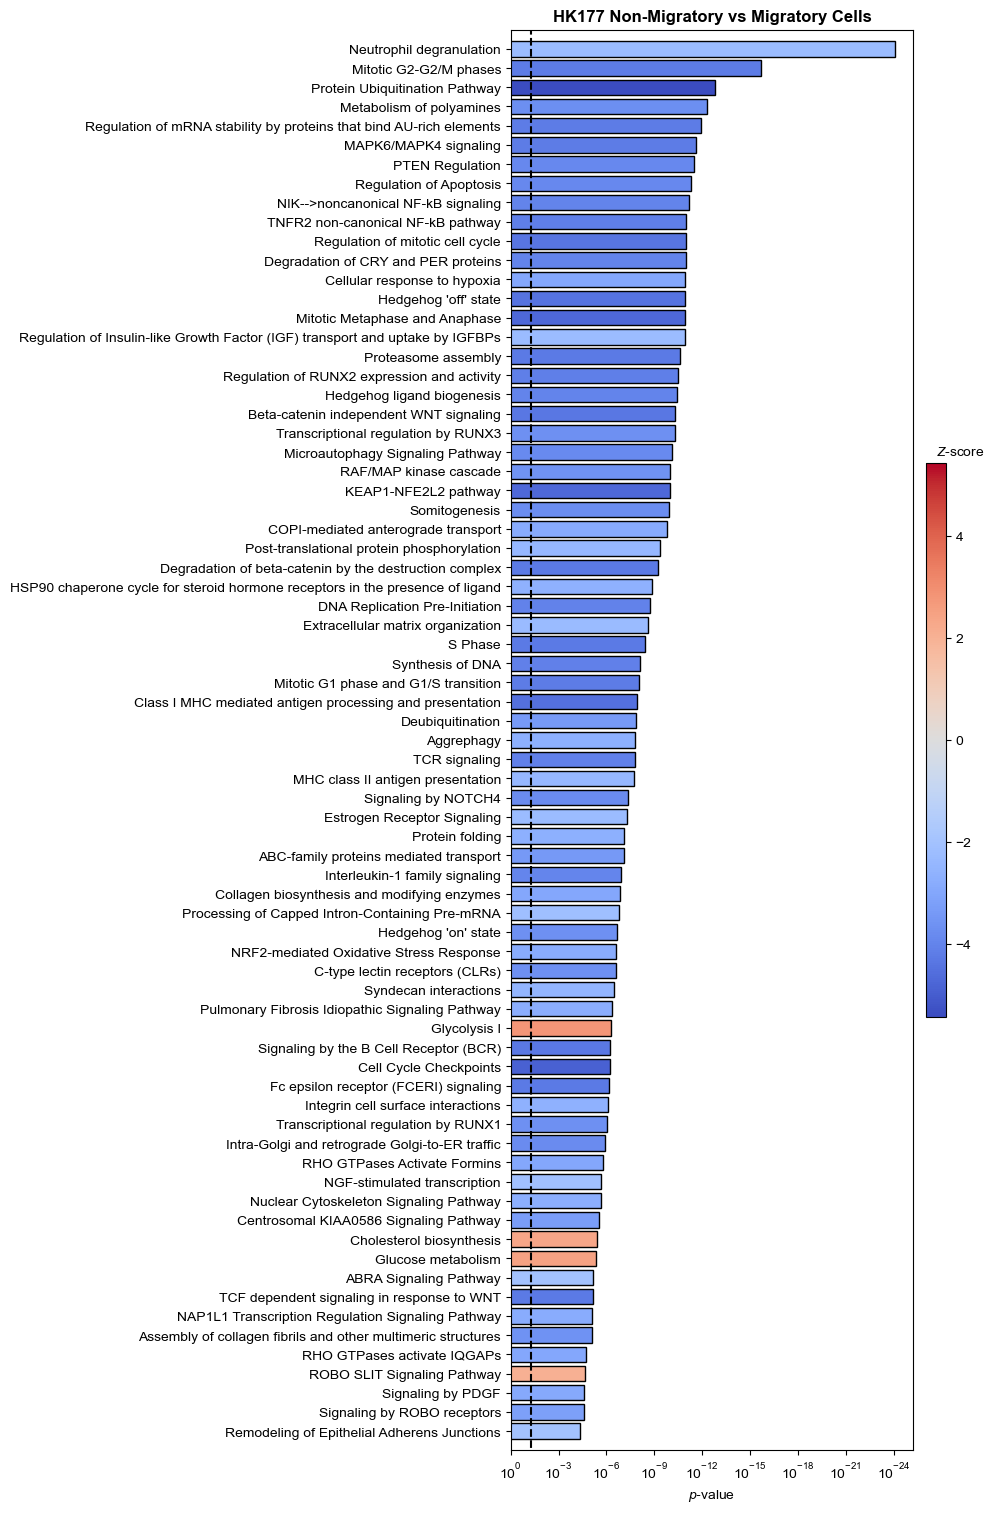

In [29]:
paths_barplot(
    hk177_top_vs_bottom.get_pathways(
        min_p=-np.log10(0.00005),
        min_abs_z=2,
        non_nan=True,
        sort_values='-log(p-value)'
    ),
    title='HK177 Non-Migratory vs Migratory Cells'
)
#plt.savefig('figures/hk177_top_vs_bottom_pathways_full.svg', bbox_inches='tight')

/tmp/ipykernel_4166824/3962488590.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels([l.get_text().replace('10^{', '10^{-') .replace('10^{-0}', '10^{0}') for l in axs[0].get_xticklabels()])


Index(['PTEN Regulation', 'Microautophagy Signaling Pathway',
       'Extracellular matrix organization',
       'Collagen biosynthesis and modifying enzymes', 'Glycolysis I',
       'Integrin cell surface interactions',
       'Assembly of collagen fibrils and other multimeric structures',
       'ROBO SLIT Signaling Pathway'],
      dtype='object', name='Ingenuity Canonical Pathways')

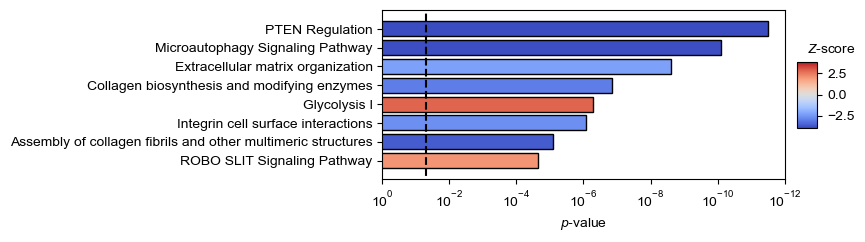

In [32]:
paths_barplot(
    hk177_top_vs_bottom.get_pathways(
        min_p=-np.log10(0.00005),
        min_abs_z=2,
        non_nan=True,
        sort_values='-log(p-value)'
    ).loc[['PTEN Regulation',
            'Microautophagy Signaling Pathway',
           'Extracellular matrix organization',
           'Collagen biosynthesis and modifying enzymes',
            'Glycolysis I',
           'Integrin cell surface interactions',
           'Assembly of collagen fibrils and other multimeric structures',
           'ROBO SLIT Signaling Pathway'],:],
    title=''
)
#plt.savefig('figures/hk177_top_vs_bottom_pathways_shortened.svg', bbox_inches='tight')

# Stiffness induced changes in cells - HK177

In [33]:
hk177_stiff_vs_soft.get_molecules(
    max_p=0.05,
    min_abs_lfc=0.2,
    sort_values='Expr Log Ratio'
).head(20)

,Entrez Gene Name,Gene Symbol - human (HUGO / HGNC / Entrez Gene),Expr Log Ratio,Expr p-value,Location,Type(s),Biomarker Application(s),Drug(s),Entrez Gene ID for Human,Entrez Gene ID for Mouse,Entrez Gene ID for Rat
Symbol,,,,,,,,,,,
MT1X,metallothionein 1X,MT1X,-0.585,3.670000e-26,Other,other,diagnosis,NaN,,,
TMEM158,transmembrane protein 158,TMEM158,-0.377,8.960000e-11,Plasma Membrane,other,NaN,NaN,,,
PLIN2,perilipin 2,PLIN2,-0.377,2.340000e-11,Plasma Membrane,other,disease progression,NaN,,,
SERPINE1,serpin family E member 1,SERPINE1,-0.375,2.800000e-10,Extracellular Space,other,"diagnosis,disease progression,efficacy,prognos...","dimethylaminomicheliolide,drotrecogin alfa,TM5614",,,
ANGPTL4,angiopoietin like 4,ANGPTL4,-0.372,1.390000e-13,Extracellular Space,other,NaN,NaN,,,
STC1,stanniocalcin 1,STC1,-0.356,8.560000e-14,Extracellular Space,kinase,diagnosis,NaN,,,
HILPDA,hypoxia inducible lipid droplet associated,HILPDA,-0.347,8.150000e-12,Cytoplasm,other,diagnosis,NaN,,,
NDRG1,N-myc downstream regulated 1,NDRG1,-0.341,9.450000e-10,Nucleus,kinase,NaN,NaN,,,
APOE,apolipoprotein E,APOE,-0.341,5.090000e-08,Extracellular Space,transporter,"diagnosis,efficacy,prognosis,unspecified appli...",NaN,,,


/tmp/ipykernel_4166824/3962488590.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels([l.get_text().replace('10^{', '10^{-') .replace('10^{-0}', '10^{0}') for l in axs[0].get_xticklabels()])


Index(['Oxidative Phosphorylation', 'Respiratory electron transport',
       'Mitochondrial Dysfunction',
       'Neutrophil Extracellular Trap Signaling Pathway',
       'Complex I biogenesis', 'Neutrophil degranulation',
       'Extracellular matrix organization', 'Granzyme A Signaling',
       'Assembly of collagen fibrils and other multimeric structures',
       'Post-translational protein phosphorylation',
       'Regulation of Insulin-like Growth Factor (IGF) transport and uptake by IGFBPs',
       'Response to elevated platelet cytosolic Ca2+',
       'Mitochondrial protein degradation', 'Cellular response to hypoxia',
       'Complex IV assembly', 'Cristae formation',
       'Formation of ATP by chemiosmotic coupling',
       'Microautophagy Signaling Pathway',
       'Collagen biosynthesis and modifying enzymes',
       'Parkinson's Signaling Pathway', 'Protein Ubiquitination Pathway',
       'Integrin cell surface interactions', 'Elastic fibre formation',
       'Class I MHC 

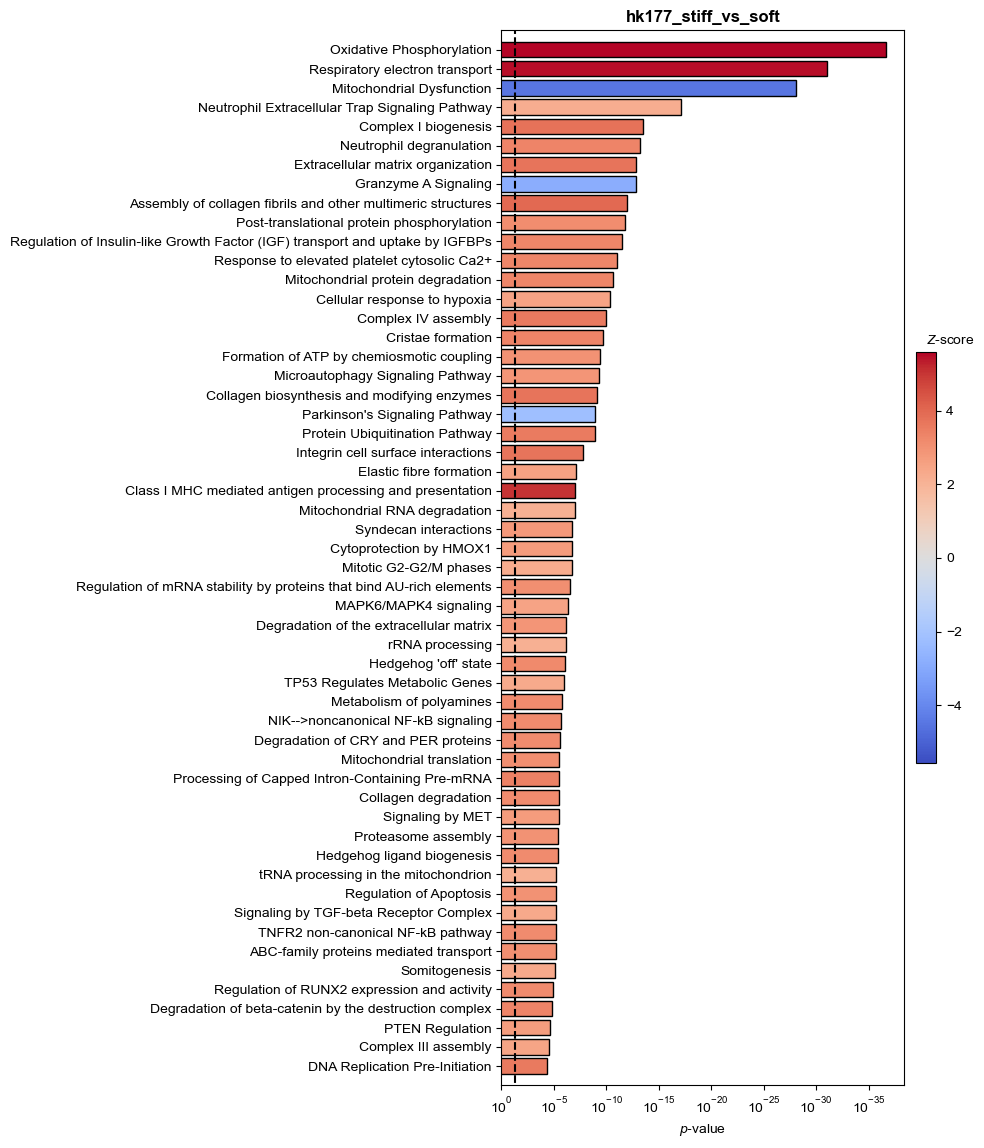

In [34]:
paths_barplot(
    hk177_stiff_vs_soft.get_pathways(
        min_p=-np.log10(0.00005),
        min_abs_z=2,
        non_nan=True,
        sort_values='-log(p-value)'
    ),
    title='hk177_stiff_vs_soft'
)

In [35]:
hk177_stiffnon_vs_softnon.get_molecules(
    max_p=0.05,
    min_abs_lfc=0.2,
    sort_values='Expr Log Ratio'
).head(20)

,Entrez Gene Name,Gene Symbol - human (HUGO / HGNC / Entrez Gene),Expr Log Ratio,Expr p-value,Location,Type(s),Biomarker Application(s),Drug(s),Entrez Gene ID for Human,Entrez Gene ID for Mouse,Entrez Gene ID for Rat
Symbol,,,,,,,,,,,
MT1X,metallothionein 1X,MT1X,-1.189,2.820000e-46,Other,other,diagnosis,NaN,,,
TMEM158,transmembrane protein 158,TMEM158,-0.766,1.940000e-22,Plasma Membrane,other,NaN,NaN,,,
STC1,stanniocalcin 1,STC1,-0.757,2.500000e-30,Extracellular Space,kinase,diagnosis,NaN,,,
ANGPTL4,angiopoietin like 4,ANGPTL4,-0.666,5.850000e-27,Extracellular Space,other,NaN,NaN,,,
SERPINE1,serpin family E member 1,SERPINE1,-0.656,6.810000e-19,Extracellular Space,other,"diagnosis,disease progression,efficacy,prognos...","dimethylaminomicheliolide,drotrecogin alfa,TM5614",,,
SLAMF9,SLAM family member 9,SLAMF9,-0.636,2.640000e-31,Extracellular Space,other,NaN,NaN,,,
NDRG1,N-myc downstream regulated 1,NDRG1,-0.570,2.810000e-16,Nucleus,kinase,NaN,NaN,,,
APOE,apolipoprotein E,APOE,-0.559,2.100000e-11,Extracellular Space,transporter,"diagnosis,efficacy,prognosis,unspecified appli...",NaN,,,
PLIN2,perilipin 2,PLIN2,-0.555,1.090000e-14,Plasma Membrane,other,disease progression,NaN,,,


/tmp/ipykernel_4166824/3962488590.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels([l.get_text().replace('10^{', '10^{-') .replace('10^{-0}', '10^{0}') for l in axs[0].get_xticklabels()])


Index(['Oxidative Phosphorylation', 'Respiratory electron transport',
       'Mitochondrial Dysfunction', 'Sirtuin Signaling Pathway',
       'Complex I biogenesis', 'Neutrophil degranulation',
       'Estrogen Receptor Signaling',
       'Neutrophil Extracellular Trap Signaling Pathway',
       'Granzyme A Signaling', 'Protein Ubiquitination Pathway',
       ...
       'Virus Entry via Endocytic Pathways', 'Iron uptake and transport',
       'rRNA processing', 'Aldosterone Signaling in Epithelial Cells',
       'Glutaryl-CoA Degradation', 'Amino acids regulate mTORC1',
       'tRNA processing in the mitochondrion', 'Collagen degradation',
       'COPII-mediated vesicle transport',
       'Actin Nucleation by ARP-WASP Complex'],
      dtype='object', name='Ingenuity Canonical Pathways', length=116)

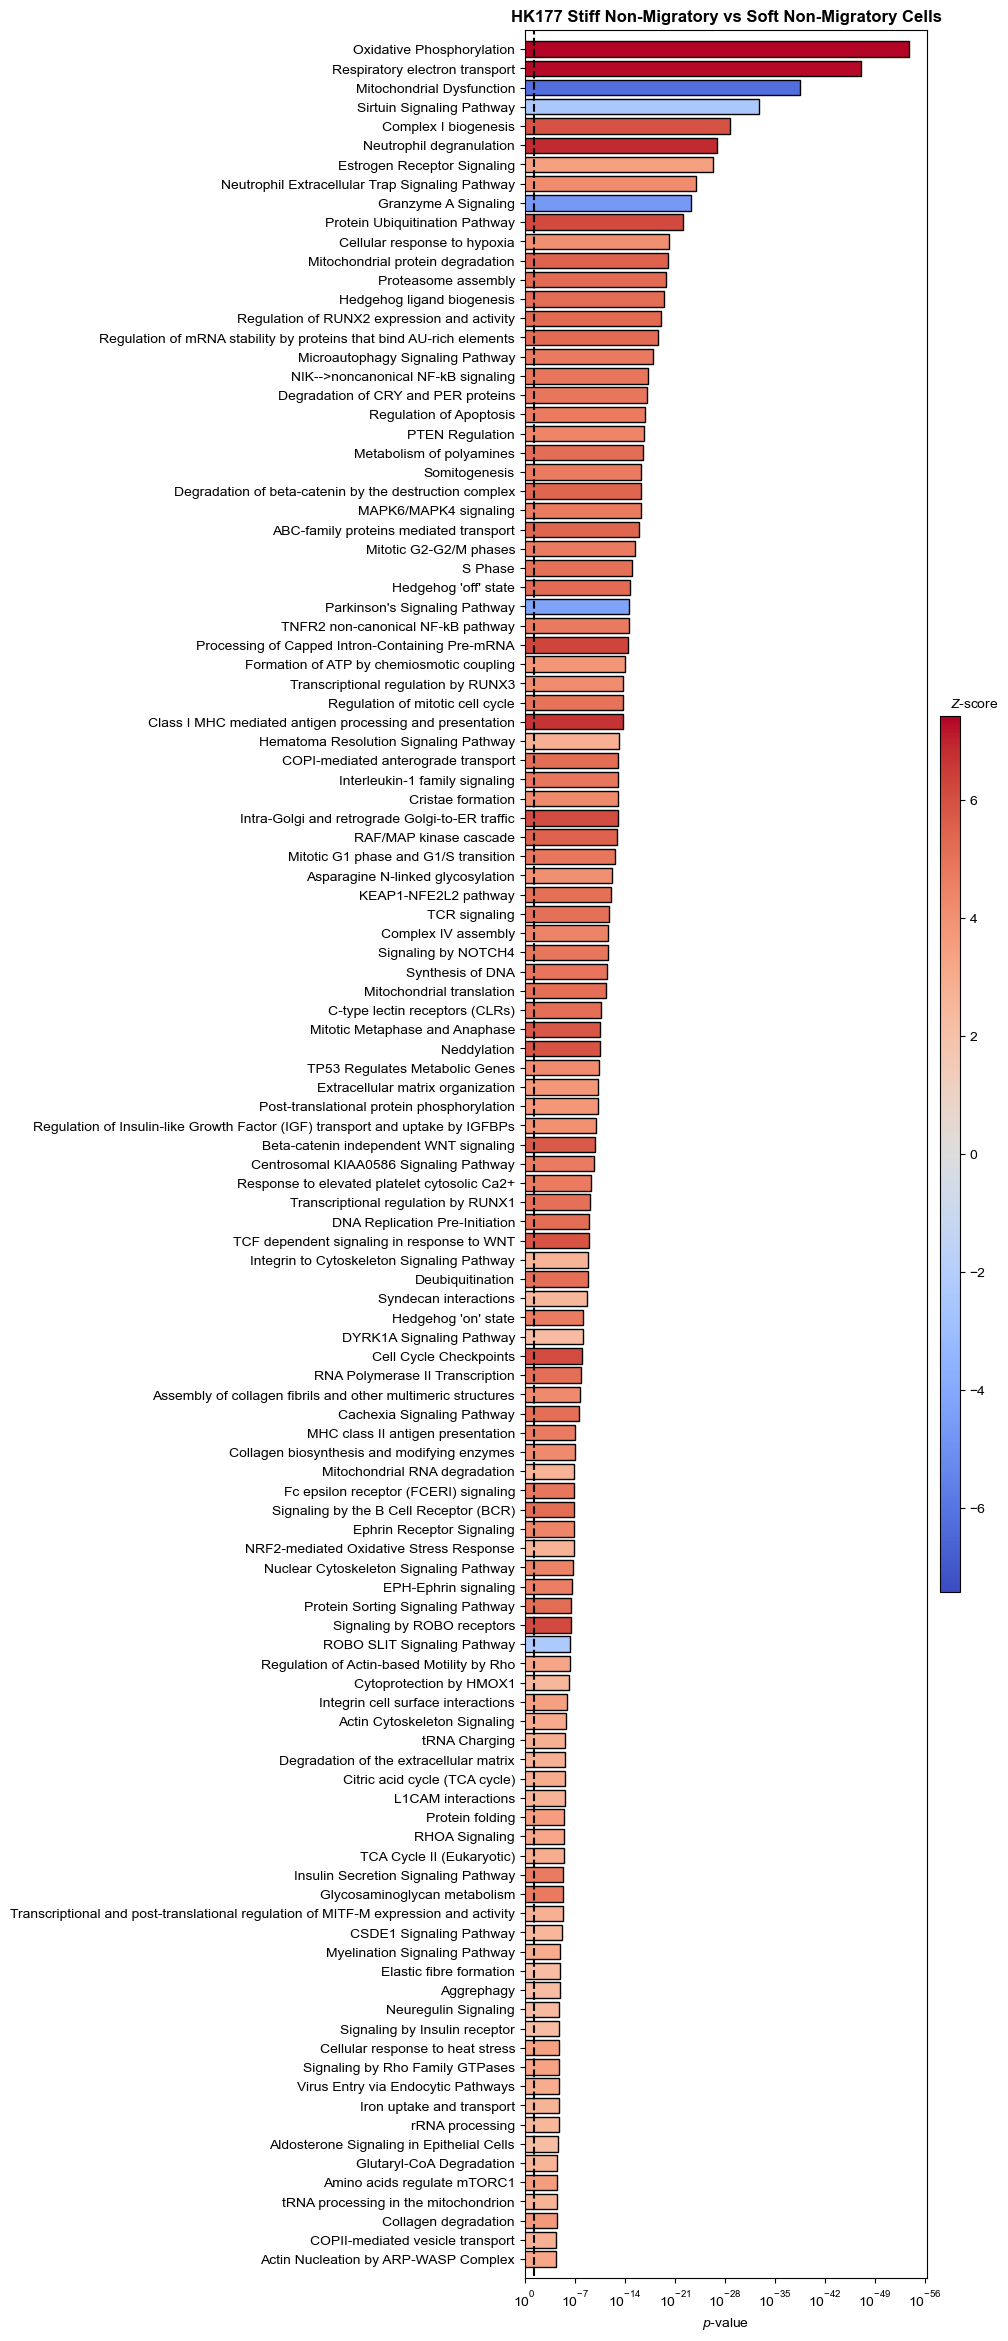

In [36]:
paths_barplot(
    hk177_stiffnon_vs_softnon.get_pathways(
        min_p=-np.log10(0.00005),
        min_abs_z=2.2,
        non_nan=True,
        sort_values='-log(p-value)'
    ),
    title='HK177 Stiff Non-Migratory vs Soft Non-Migratory Cells'
)
#plt.savefig('figures/hk177_stiffnon_vs_softnon_pathways_full.svg', bbox_inches='tight')

/tmp/ipykernel_4166824/3962488590.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels([l.get_text().replace('10^{', '10^{-') .replace('10^{-0}', '10^{0}') for l in axs[0].get_xticklabels()])


Index(['Oxidative Phosphorylation', 'Sirtuin Signaling Pathway',
       'Degradation of beta-catenin by the destruction complex',
       'Asparagine N-linked glycosylation',
       'Extracellular matrix organization',
       'Assembly of collagen fibrils and other multimeric structures',
       'Collagen biosynthesis and modifying enzymes',
       'Regulation of Actin-based Motility by Rho',
       'Actin Cytoskeleton Signaling', 'Collagen degradation'],
      dtype='object', name='Ingenuity Canonical Pathways')

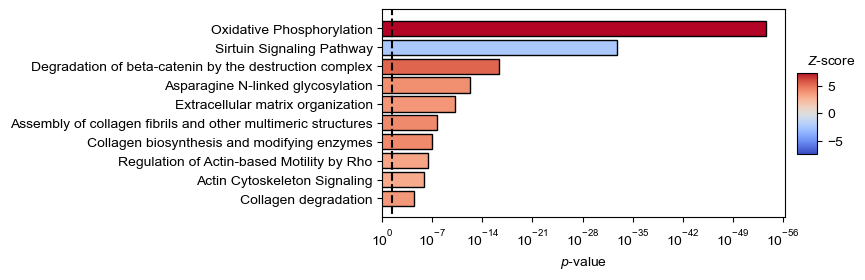

In [37]:
paths_barplot(
    hk177_stiffnon_vs_softnon.get_pathways(
        min_p=-np.log10(0.00005),
        min_abs_z=2,
        non_nan=True,
        sort_values='-log(p-value)'
    ).loc[['Oxidative Phosphorylation',
           'Sirtuin Signaling Pathway',
           'Degradation of beta-catenin by the destruction complex',
           'Asparagine N-linked glycosylation',
           'Extracellular matrix organization',
           'Assembly of collagen fibrils and other multimeric structures',
           'Collagen biosynthesis and modifying enzymes',
           'Regulation of Actin-based Motility by Rho',
           'Actin Cytoskeleton Signaling',
           'Collagen degradation'],:],
    title=''
)

/tmp/ipykernel_4166824/3962488590.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels([l.get_text().replace('10^{', '10^{-') .replace('10^{-0}', '10^{0}') for l in axs[0].get_xticklabels()])


Index(['EIF2 Signaling', 'Nonsense-Mediated Decay (NMD)',
       'Response of EIF2AK4 (GCN2) to amino acid deficiency',
       'Signaling by ROBO receptors', 'Eukaryotic Translation Initiation',
       'GAIT Translation Signaling Pathway', 'Exosome Signaling Pathway',
       'Eukaryotic Translation Elongation',
       'Eukaryotic Translation Termination',
       'SRP-dependent cotranslational protein targeting to membrane',
       'Ribosomal Quality Control Signaling Pathway',
       'Selenoamino acid metabolism',
       'Major pathway of rRNA processing in the nucleolus and cytosol',
       'Processing of Capped Intron-Containing Pre-mRNA',
       'Stress Granule Signaling Pathway', 'Protein Ubiquitination Pathway',
       'RHO GTPase cycle', 'Deubiquitination', 'RAF/MAP kinase cascade',
       'Chromatin modifying enzymes', 'Histone Modification Signaling Pathway',
       'Class I MHC mediated antigen processing and presentation',
       'RNA Polymerase II Transcription', 'Coronaviru

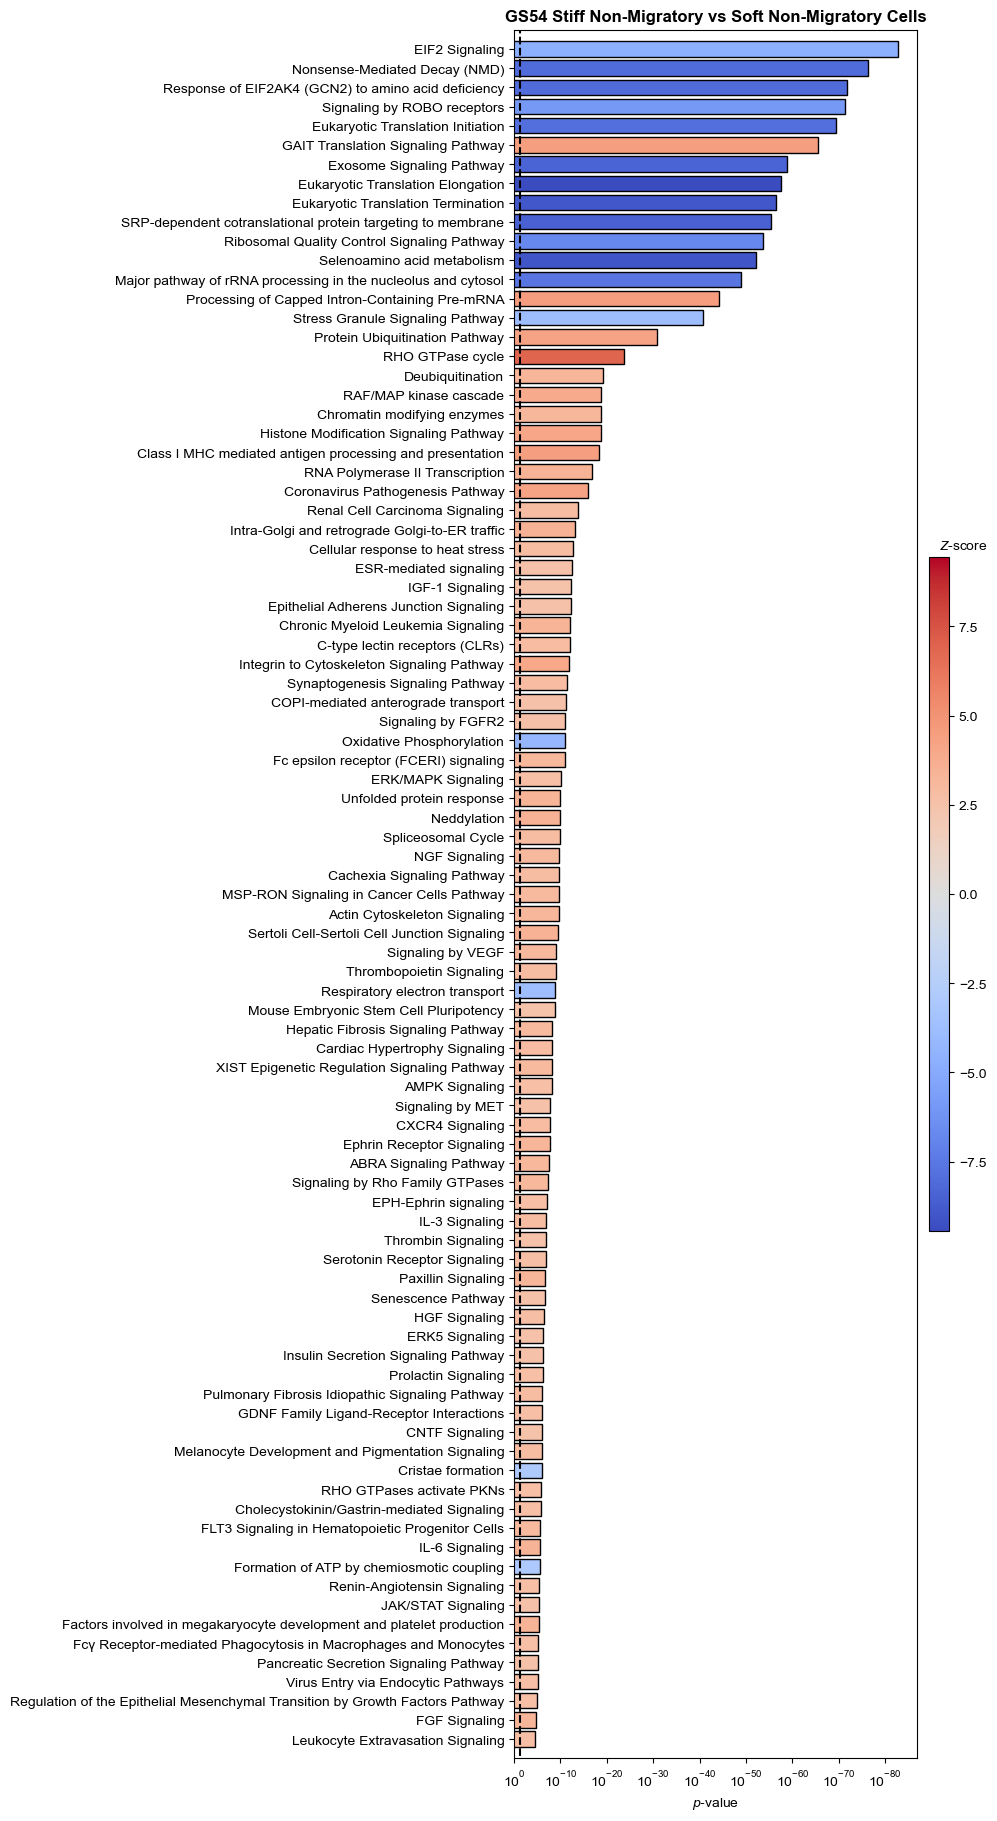

In [38]:
paths_barplot(
    gs54_stiffnon_vs_softnon.get_pathways(
        min_p=-np.log10(0.00005),
        min_abs_z=2.5,
        non_nan=True,
        sort_values='-log(p-value)'
    ),
    title='GS54 Stiff Non-Migratory vs Soft Non-Migratory Cells'
)
#plt.savefig('figures/gs54_stiffnon_vs_softnon_pathways_full.svg', bbox_inches='tight')

In [39]:
gs54_top_vs_bottom.get_molecules(
    max_p=0.05,
    min_abs_lfc=0.2,
    sort_values='Expr Log Ratio'
).head(20)

,Entrez Gene Name,Gene Symbol - human (HUGO / HGNC / Entrez Gene),Expr Log Ratio,Expr p-value,Location,Type(s),Biomarker Application(s),Drug(s),Entrez Gene ID for Human,Entrez Gene ID for Mouse,Entrez Gene ID for Rat
Symbol,,,,,,,,,,,
MALAT1,metastasis associated lung adenocarcinoma tran...,MALAT1,-0.780,4.840000e-115,Nucleus,other,NaN,NaN,,,
COL11A1,collagen type XI alpha 1 chain,COL11A1,-0.745,1.340000e-111,Extracellular Space,other,NaN,collagenase,,,
MTRNR2L6,MT-RNR2 like 6 (pseudogene),MTRNR2L6,-0.682,2.450000e-90,Other,other,NaN,NaN,,,
ZBTB20,zinc finger and BTB domain containing 20,ZBTB20,-0.609,9.650000e-109,Nucleus,transcription regulator,NaN,NaN,,,
VEGFA,vascular endothelial growth factor A,VEGFA,-0.590,1.850000e-92,Extracellular Space,growth factor,"diagnosis,efficacy,prognosis,safety,unspecifie...","aflibercept,aflibercept/bevacizumab,aflibercep...",,,
SPARC,secreted protein acidic and cysteine rich,SPARC,-0.549,7.470000e-173,Extracellular Space,other,"disease progression,efficacy",NaN,,,
SOX4,SRY-box transcription factor 4,SOX4,-0.536,2.970000e-68,Nucleus,transcription regulator,unspecified application,NaN,,,
PNISR,PNN interacting serine and arginine rich protein,PNISR,-0.534,1.880000e-94,Nucleus,other,NaN,NaN,,,
CRYAB,crystallin alpha B,CRYAB,-0.530,5.110000e-77,Nucleus,other,"diagnosis,disease progression,prognosis,unspec...",NaN,,,


/tmp/ipykernel_4166824/3962488590.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels([l.get_text().replace('10^{', '10^{-') .replace('10^{-0}', '10^{0}') for l in axs[0].get_xticklabels()])


Index(['Signaling by ROBO receptors',
       'Processing of Capped Intron-Containing Pre-mRNA', 'EIF2 Signaling',
       'Nonsense-Mediated Decay (NMD)', 'Eukaryotic Translation Initiation',
       'Response of EIF2AK4 (GCN2) to amino acid deficiency',
       'GAIT Translation Signaling Pathway',
       'Ribosomal Quality Control Signaling Pathway',
       'Major pathway of rRNA processing in the nucleolus and cytosol',
       'SRP-dependent cotranslational protein targeting to membrane',
       ...
       'RNA Polymerase I Transcription',
       'Cytosolic sensors of pathogen-associated DNA', 'tRNA Charging',
       'Activation of anterior HOX genes in hindbrain during early embryogenesis',
       'Necroptosis Signaling Pathway', 'mRNA Capping',
       'NoRC negatively regulates rRNA expression',
       'Senescence-Associated Secretory Phenotype (SASP)',
       'Regulation of TP53 Activity through Phosphorylation',
       'Mitotic Prophase'],
      dtype='object', name='Ingenuity Cano

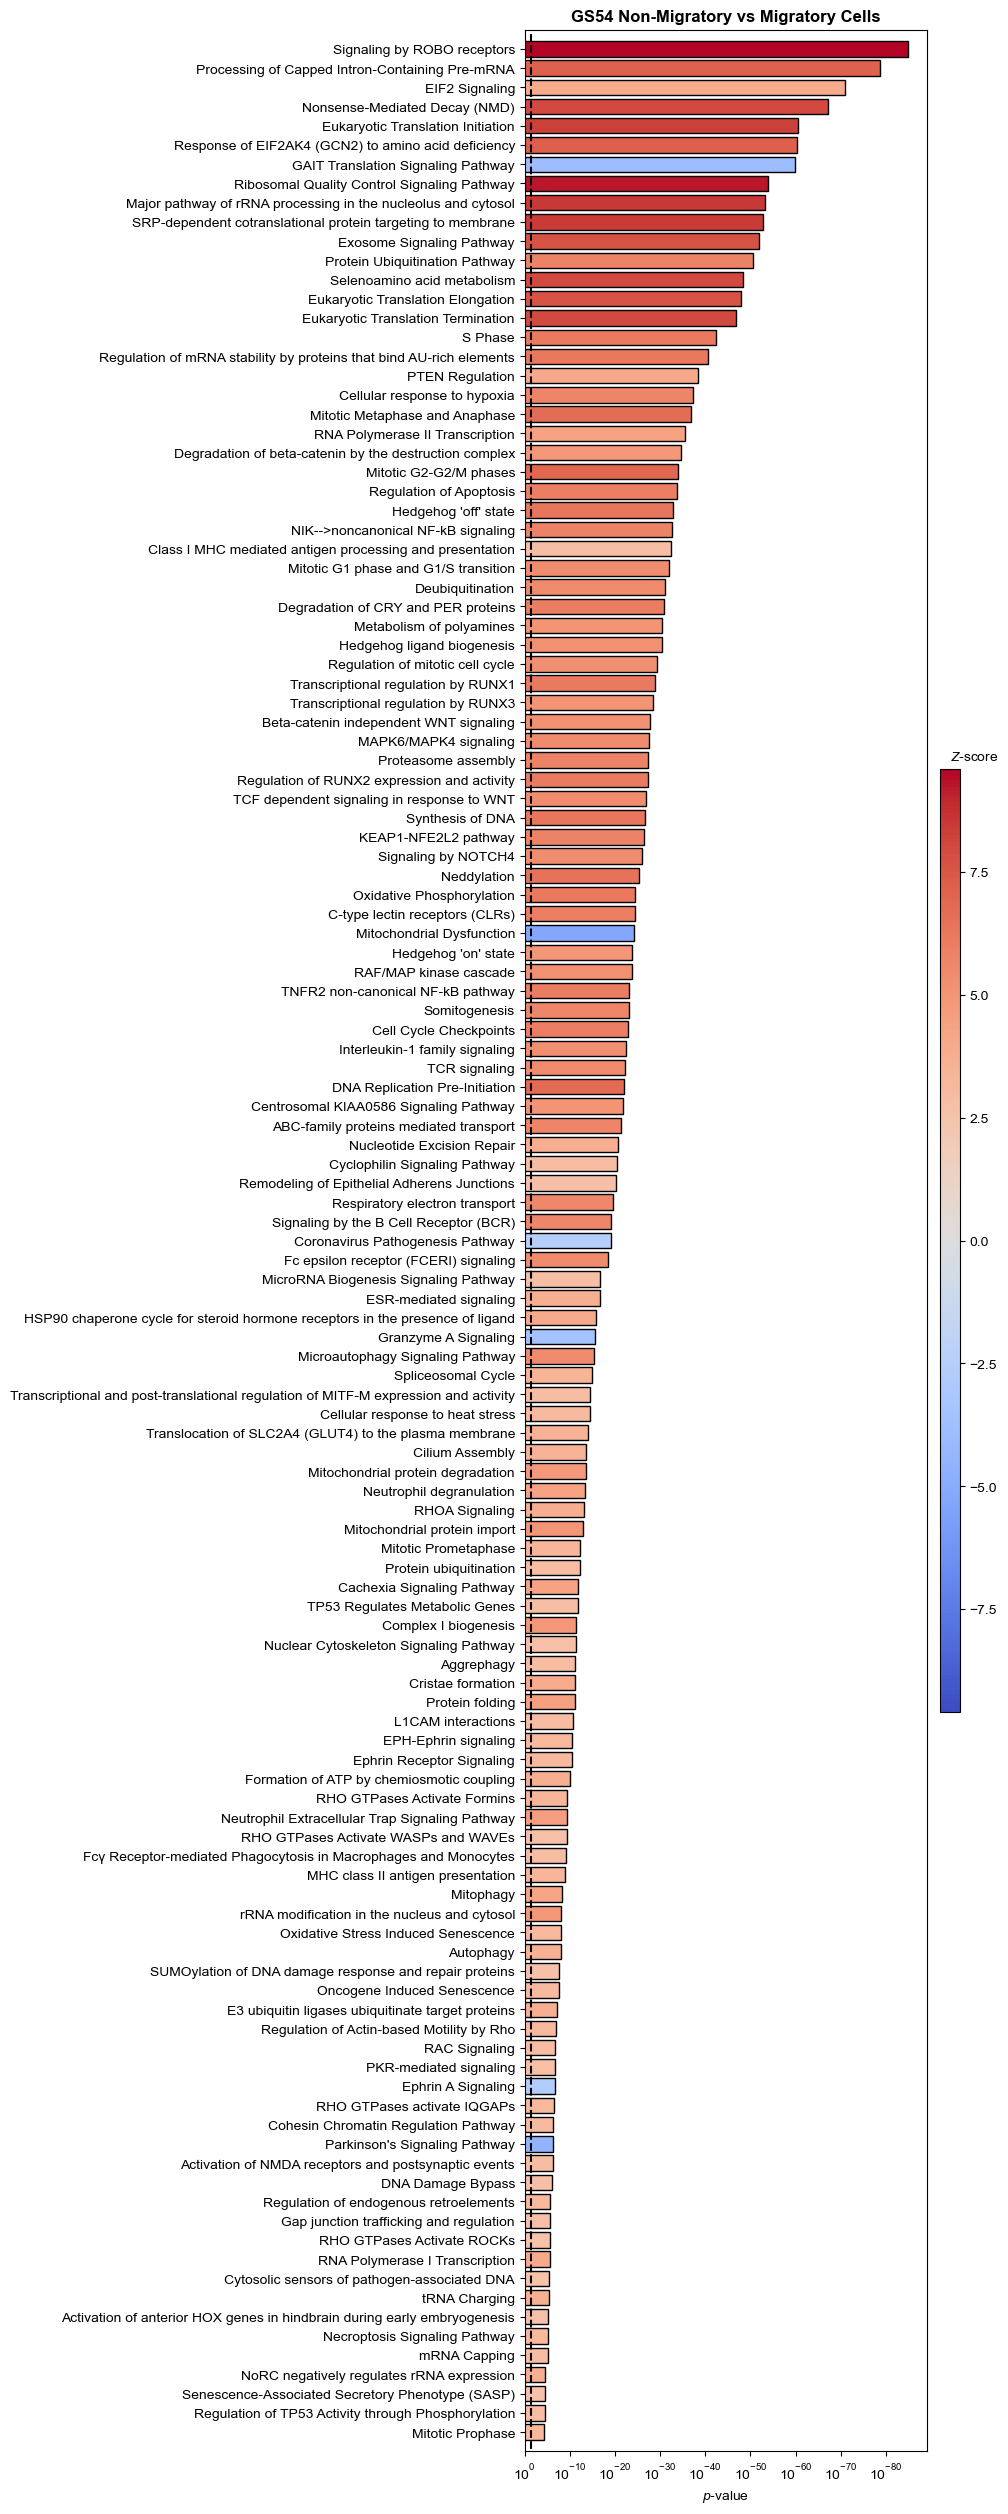

In [40]:
paths_barplot(
    gs54_top_vs_bottom.get_pathways(
        min_p=-np.log10(0.00005),
        min_abs_z=2.5,
        non_nan=True,
        sort_values='-log(p-value)'
    ),
    title='GS54 Non-Migratory vs Migratory Cells'
)
#plt.savefig('figures/gs54_top_vs_bottom_pathways_full.svg', bbox_inches='tight')

/tmp/ipykernel_4166824/3962488590.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels([l.get_text().replace('10^{', '10^{-') .replace('10^{-0}', '10^{0}') for l in axs[0].get_xticklabels()])


Index(['Signaling by ROBO receptors', 'EIF2 Signaling',
       'GAIT Translation Signaling Pathway', 'Cellular response to hypoxia',
       'Remodeling of Epithelial Adherens Junctions',
       'Actin Cytoskeleton Signaling', 'RHOA Signaling',
       'RHO GTPases Activate Formins',
       'Regulation of Actin-based Motility by Rho'],
      dtype='object', name='Ingenuity Canonical Pathways')

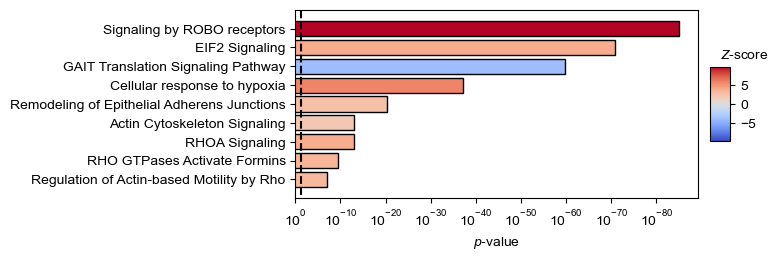

In [43]:
paths_barplot(
    gs54_top_vs_bottom.get_pathways(
        min_p=-np.log10(0.00005),
        min_abs_z=2,
        non_nan=True,
        sort_values='-log(p-value)'
    ).loc[['Signaling by ROBO receptors',
           'EIF2 Signaling',
           'GAIT Translation Signaling Pathway',
           'Cellular response to hypoxia',
           'Remodeling of Epithelial Adherens Junctions',
           'Actin Cytoskeleton Signaling',
           'RHOA Signaling',
           'RHO GTPases Activate Formins',
           'Regulation of Actin-based Motility by Rho'],:],
    title= ''#'GS54 Non-Migratory vs Migratory Cell Pathways'
)
#plt.savefig('figures/gs54_top_vs_bottom_pathways_shortened.svg', bbox_inches='tight')

# Subpopulations

In [44]:
misubp_vs_nonmisubp.get_molecules(
    max_p=0.05,
    min_abs_lfc=0.2,
    sort_values='Expr Log Ratio'
).head(20)

,Entrez Gene Name,Gene Symbol - human (HUGO / HGNC / Entrez Gene),Expr Log Ratio,Expr p-value,Location,Type(s),Biomarker Application(s),Drug(s),Entrez Gene ID for Human,Entrez Gene ID for Mouse,Entrez Gene ID for Rat
Symbol,,,,,,,,,,,
PCAT1,prostate cancer associated transcript 1,PCAT1,-0.768,1.970000e-93,Other,other,NaN,NaN,,,
SLAMF9,SLAM family member 9,SLAMF9,-0.725,4.150000e-25,Extracellular Space,other,NaN,NaN,,,
BGN,biglycan,BGN,-0.693,1.250000e-52,Extracellular Space,other,NaN,NaN,,,
PVT1,Pvt1 oncogene,PVT1,-0.523,4.990000e-09,Other,other,"safety,unspecified application",NaN,,,
TGFBI,transforming growth factor beta induced,TGFBI,-0.486,6.890000e-16,Extracellular Space,other,NaN,NaN,,,
STAC2,SH3 and cysteine rich domain 2,STAC2,-0.412,3.950000e-15,Plasma Membrane,other,NaN,NaN,,,
NDRG1,N-myc downstream regulated 1,NDRG1,-0.375,1.230000e-04,Nucleus,kinase,NaN,NaN,,,
IGFBP2,insulin like growth factor binding protein 2,IGFBP2,-0.369,6.230000e-17,Extracellular Space,other,"diagnosis,efficacy,prognosis",NaN,,,
DMKN,dermokine,DMKN,-0.335,4.090000e-15,Extracellular Space,other,NaN,NaN,,,


/tmp/ipykernel_4166824/3962488590.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels([l.get_text().replace('10^{', '10^{-') .replace('10^{-0}', '10^{0}') for l in axs[0].get_xticklabels()])


Index(['Neutrophil degranulation', 'Granzyme A Signaling',
       'Regulation of Insulin-like Growth Factor (IGF) transport and uptake by IGFBPs',
       'Respiratory electron transport',
       'Post-translational protein phosphorylation',
       'Mitochondrial RNA degradation', 'Oxidative Phosphorylation',
       'rRNA processing', 'Estrogen Receptor Signaling',
       'Extra-nuclear estrogen signaling', 'MHC class II antigen presentation',
       'Mitochondrial translation',
       'Integrin to Cytoskeleton Signaling Pathway',
       'Nuclear Cytoskeleton Signaling Pathway', 'Complex I biogenesis',
       'Sirtuin Signaling Pathway', 'tRNA processing in the mitochondrion',
       'Membrane Repair Signaling Pathway', 'PTEN Signaling', 'Aggrephagy',
       'Metallothioneins bind metals', 'Signaling by Rho Family GTPases',
       'Protein folding', 'RHO GTPases Activate Formins',
       'Actin Cytoskeleton Signaling',
       'Interleukin-4 and Interleukin-13 signaling',
       'HSP90 c

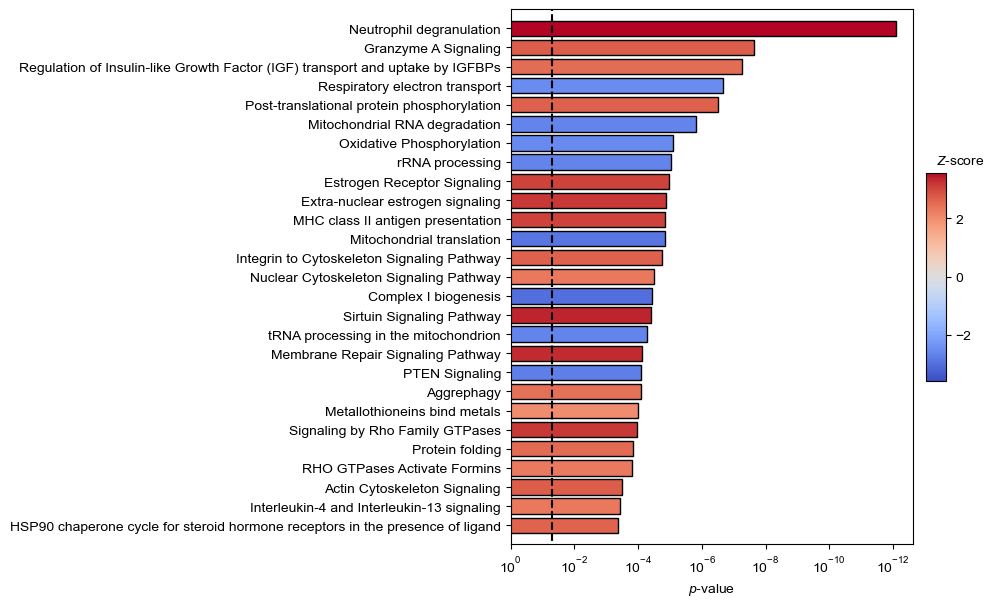

In [45]:
paths_barplot(
    misubp_vs_nonmisubp.get_pathways(
        min_p=-np.log10(0.0005),
        min_abs_z=2,
        non_nan=True,
        sort_values='-log(p-value)'
    ),
    title=''
)

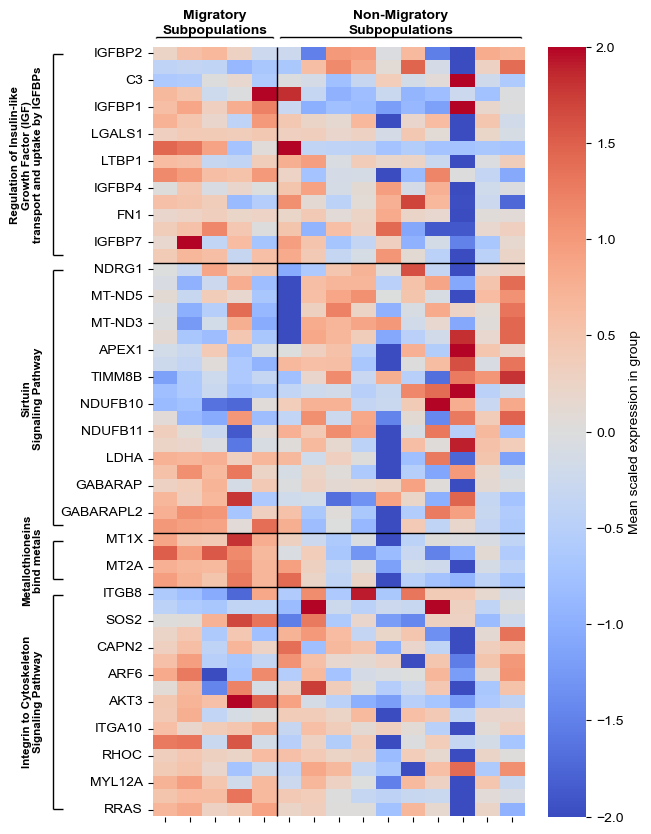

In [46]:
grouped_heatmap_lin(
    ad_hk177_sub, 
    misubp_vs_nonmisubp, 
    'lineage',
    ['Regulation of Insulin-like\nGrowth Factor (IGF)\ntransport and uptake by IGFBPs', 'Sirtuin\nSignaling Pathway', 'Metallothioneins\nbind metals', 'Integrin to Cytoskeleton\nSignaling Pathway'], 
    {
        'Migratory\nSubpopulations':np.unique(ad_hk177_sub.obs.loc[ad_hk177_sub.obs['phenotype'] == 'migratory', 'lineage']), 
        'Non-Migratory\nSubpopulations':np.unique(ad_hk177_sub.obs.loc[ad_hk177_sub.obs['phenotype'] == 'nonmigratory', 'lineage'])
    },
    figsize=(6, 10), 
    textx=-4, texty=-0.7,
    cmap='coolwarm',
    vmax=2, vmin=-2, center=0.
)